In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib  # Used to save our final production workflow file


In [2]:
df=pd.read_csv("AB_NYC_2019.CSV")

df=df.drop(columns=["host_id","id","last_review","host_name","name"])
df.columns
df.head(2)
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  str    
 1   neighbourhood                   48895 non-null  str    
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  str    
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               38843 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 5.7 MB


neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

   price  log_price
0    149   5.010635
1    225   5.420535
2    150   5.017280
3     89   4.499810
4     80   4.394449


np.float64(0.2352397532745499)

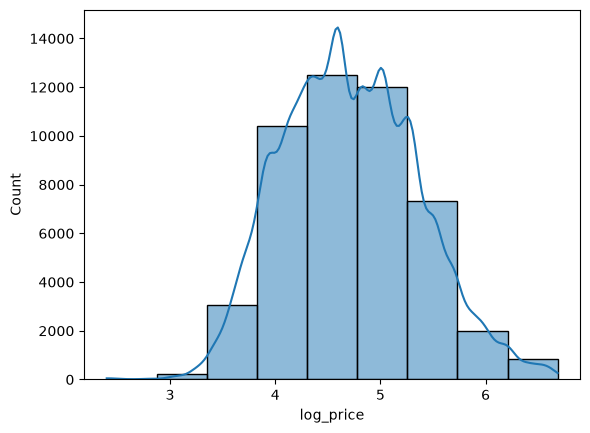

In [3]:
# Fill missing reviews with 0.0
df['reviews_per_month'] = df['reviews_per_month'].fillna(0.0)


# Keep only listings where the price is greater than 0
df = df[df['price'] > 0]
price_cap=df['price'].quantile(0.99)
df=df[df["price"]<=price_cap]
df['log_price'] = np.log1p(df['price'])
print(df[['price','log_price']].head())
sns.histplot(data=df, x="log_price", binwidth=0.50, kde=True)
df["log_price"].skew()


In [10]:

# Count listings that originally had minimum_nights > 365

count_capped = (df['minimum_nights'] > 365).sum()

print("Number of listings capped at 365:", count_capped)

df['minimum_nights'] = df['minimum_nights'].clip(upper=365)
print(df['minimum_nights'].max())
df.shape
df.columns
df.isnull().sum()
df.head()


Number of listings capped at 365: 0
365


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,5.010635
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,5.420535
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,5.017280
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,4.499810
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,4.394449


In [5]:
from sklearn.model_selection import train_test_split

# Split the data while features are still raw text
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=["price","log_price","neighbourhood"]),df["log_price"], test_size=0.2, random_state=42)

print(f"Raw Training data shape: {X_train.shape}")
print(f"Raw Testing data shape: {X_test.shape}")

categorical_cols = ['neighbourhood_group', 'room_type']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)


Raw Training data shape: (38728, 9)
Raw Testing data shape: (9682, 9)


In [7]:
# Define hyperparameter grids for each model
param_grids = {
    'Decision Tree': {
        'regressor__max_depth': [8, 10, 12, 14, 16],
        'regressor__min_samples_split': [5, 10, 15],
        'regressor__min_samples_leaf': [2, 4, 6]
    },
    'Random Forest': {
        'regressor__n_estimators': [50, 100, 150],
        'regressor__max_depth': [10, 12, 15],
        'regressor__min_samples_split': [5, 10],
        'regressor__min_samples_leaf': [2, 4]
    }
}

# Create base pipelines
base_pipelines = {
    'Decision Tree': Pipeline([('preprocessor', preprocessor), ('regressor', DecisionTreeRegressor(random_state=42))]),
    'Random Forest': Pipeline([('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))])
}

# Train with GridSearchCV
results = {}
for name, pipe in base_pipelines.items():
    print(f"\n🔍 GridSearchCV for {name}...")
    
    # Create GridSearchCV
    grid_search = GridSearchCV(
        pipe, 
        param_grids[name], 
        cv=5,  # 5-fold cross-validation
        scoring='neg_mean_absolute_error',
        n_jobs=-1,  # Use all processors
        verbose=1
    )
    
    # Fit GridSearchCV
    grid_search.fit(X_train, y_train)
    
    # Store results
    results[name] = grid_search
    best_model = grid_search.best_estimator_
    
    # Evaluate best model
    train_preds = np.expm1(best_model.predict(X_train))
    test_preds = np.expm1(best_model.predict(X_test))
    
    real_y_train = np.expm1(y_train)
    real_y_test = np.expm1(y_test)
    
    train_mae = mean_absolute_error(real_y_train, train_preds)
    test_mae = mean_absolute_error(real_y_test, test_preds)
    test_r2 = r2_score(real_y_test, test_preds)
    
    print(f"\n=== {name} - Best Hyperparameters ===")
    print(f"Best Params: {grid_search.best_params_}")
    print(f"Best CV Score: ${-grid_search.best_score_:.2f}")
    print(f"\nTrain Error (MAE): ${train_mae:.2f}")
    print(f"Test Error (MAE):  ${test_mae:.2f}")
    print(f"Test R² Score:     {test_r2:.2f}")
    
    if train_mae < (test_mae * 0.7):
        print("⚠️ Diagnosis: Model shows signs of Overfitting.")
    else:
        print("✅ Diagnosis: Model generalization looks balanced.")
    print("-" * 40)

# Select best overall model
# Correct line (picks -0.29 over -0.31):
best_overall = max(results.items(), key=lambda x: x[1].best_score_)
print(f"\n🏆 Best Model: {best_overall[0]}")



🔍 GridSearchCV for Decision Tree...
Fitting 5 folds for each of 45 candidates, totalling 225 fits

=== Decision Tree - Best Hyperparameters ===
Best Params: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 6, 'regressor__min_samples_split': 5}
Best CV Score: $0.31

Train Error (MAE): $42.24
Test Error (MAE):  $44.75
Test R² Score:     0.45
✅ Diagnosis: Model generalization looks balanced.
----------------------------------------

🔍 GridSearchCV for Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Random Forest - Best Hyperparameters ===
Best Params: {'regressor__max_depth': 15, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 150}
Best CV Score: $0.29

Train Error (MAE): $32.00
Test Error (MAE):  $41.85
Test R² Score:     0.51
✅ Diagnosis: Model generalization looks balanced.
----------------------------------------

🏆 Best Model: Random Forest


In [11]:
import joblib

# Get the best model from GridSearchCV results
best_model_name = max(results.items(), key=lambda x: -x[1].best_score_)[0]
best_pipeline = results[best_model_name].best_estimator_

# Save the tuned pipeline
joblib.dump(best_pipeline, 'airbnb_model_pipeline.pkl', compress=3)

print(f"🎉 Success! The {best_model_name} pipeline with optimized hyperparameters is saved!")
print(f"Hyperparameters: {results[best_model_name].best_params_}")


🎉 Success! The Decision Tree pipeline with optimized hyperparameters is saved!
Hyperparameters: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 6, 'regressor__min_samples_split': 5}
